Run this first to install all necessary packages and import libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')


plt.style.use('default')
sns.set_theme(style="whitegrid")

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [ ]:
from google.colab import files

print("="*60)
print("UPLOAD YOUR THREE CSV FILES")
print("="*60)

print("\n 1. Upload: ACS_5-Year_Social_Characteristics_DC_Ward.csv")
uploaded1 = files.upload()

print("\n 2. Upload: ADA_Curb_Ramp.csv")
uploaded2 = files.upload()

print("\n 3. Upload: Sidewalk_Condition_Assessment.csv")
uploaded3 = files.upload()

acs_file = list(uploaded1.keys())[0]
curb_file = list(uploaded2.keys())[0]
sidewalk_file = list(uploaded3.keys())[0]

acs_data = pd.read_csv(acs_file)
curb_data = pd.read_csv(curb_file)
sidewalk_data = pd.read_csv(sidewalk_file)

print("\n✓ ALL FILES LOADED:")
print(f"  - ACS: {acs_data.shape[0]} rows, {acs_data.shape[1]} cols")
print(f"  - Curb Ramps: {curb_data.shape[0]} rows, {curb_data.shape[1]} cols")
print(f"  - Sidewalks: {sidewalk_data.shape[0]} rows, {sidewalk_data.shape[1]} cols")

UPLOAD YOUR THREE CSV FILES

📁 1. Upload: ACS_5-Year_Social_Characteristics_DC_Ward.csv


Saving ACS_5-Year_Social_Characteristics_DC_Ward.csv to ACS_5-Year_Social_Characteristics_DC_Ward.csv

📁 2. Upload: ADA_Curb_Ramp.csv


Saving ADA_Curb_Ramp.csv to ADA_Curb_Ramp.csv

📁 3. Upload: Sidewalk_Condition_Assessment.csv


Saving Sidewalk_Condition_Assessment.csv to Sidewalk_Condition_Assessment.csv

✓ ALL FILES LOADED:
  - ACS: 8 rows, 174 cols
  - Curb Ramps: 34859 rows, 15 cols
  - Sidewalks: 24577 rows, 20 cols


Filtering for disability columns that start with DP02 codes (common in ACS)

In [ ]:
dp02_cols = [col for col in acs_data.columns if 'DP02' in col]
print("DP02 columns found:")
print(dp02_cols)
print(f"\nTotal: {len(dp02_cols)} columns")

DP02 columns found:
['DP02_0001E', 'DP02_0002E', 'DP02_0003E', 'DP02_0004E', 'DP02_0005E', 'DP02_0006E', 'DP02_0007E', 'DP02_0008E', 'DP02_0009E', 'DP02_0010E', 'DP02_0011E', 'DP02_0012E', 'DP02_0013E', 'DP02_0014E', 'DP02_0015E', 'DP02_0016E', 'DP02_0017E', 'DP02_0018E', 'DP02_0019E', 'DP02_0020E', 'DP02_0021E', 'DP02_0022E', 'DP02_0023E', 'DP02_0024E', 'DP02_0025E', 'DP02_0026E', 'DP02_0027E', 'DP02_0028E', 'DP02_0029E', 'DP02_0030E', 'DP02_0031E', 'DP02_0032E', 'DP02_0033E', 'DP02_0034E', 'DP02_0035E', 'DP02_0036E', 'DP02_0037E', 'DP02_0038E', 'DP02_0039E', 'DP02_0040E', 'DP02_0041E', 'DP02_0042E', 'DP02_0043E', 'DP02_0044E', 'DP02_0045E', 'DP02_0046E', 'DP02_0047E', 'DP02_0048E', 'DP02_0049E', 'DP02_0050E', 'DP02_0051E', 'DP02_0052E', 'DP02_0053E', 'DP02_0054E', 'DP02_0055E', 'DP02_0056E', 'DP02_0057E', 'DP02_0058E', 'DP02_0059E', 'DP02_0060E', 'DP02_0061E', 'DP02_0062E', 'DP02_0063E', 'DP02_0064E', 'DP02_0065E', 'DP02_0066E', 'DP02_0067E', 'DP02_0068E', 'DP02_0069E', 'DP02_0070E',

 Look specifically for disability-related columns (usually 0072-0081). This will show me exactly what disability columns are available

In [ ]:
import re
pattern = r'007[2-9]|008[0-1]'
disability_codes = [col for col in dp02_cols if re.search(pattern, col)]
print("Disability-related columns (0072-0081):")
print(disability_codes)

Disability-related columns (0072-0081):
['DP02_0072E', 'DP02_0073E', 'DP02_0074E', 'DP02_0075E', 'DP02_0076E', 'DP02_0077E', 'DP02_0078E', 'DP02_0079E', 'DP02_0080E', 'DP02_0081E']


Creating a data frame with descriptive names based on ACS standard definitions.

In [ ]:
disability_data = pd.DataFrame({
    'Disability_Type': [
        "Total with Disability",
        "Hearing Difficulty",
        "Vision Difficulty",
        "Cognitive Difficulty",
        "Ambulatory Difficulty",
        "Self-Care Difficulty",
        "Independent Living Difficulty"
    ],
    'Column': [
        "DP02_0072E",  # Total civilian noninstitutionalized with disability
        "DP02_0073E",  # With a hearing difficulty
        "DP02_0074E",  # With a vision difficulty
        "DP02_0075E",  # With a cognitive difficulty
        "DP02_0076E",  # With an ambulatory difficulty
        "DP02_0077E",  # With a self-care difficulty
        "DP02_0078E"   # With an independent living difficulty
    ]
})

print(disability_data)

                 Disability_Type      Column
0          Total with Disability  DP02_0072E
1             Hearing Difficulty  DP02_0073E
2              Vision Difficulty  DP02_0074E
3           Cognitive Difficulty  DP02_0075E
4          Ambulatory Difficulty  DP02_0076E
5           Self-Care Difficulty  DP02_0077E
6  Independent Living Difficulty  DP02_0078E


Forming the actual counts by summing across all wards, this creates a new column with the sum for each disability type. this chunk as remove any rows where the column wasn't found

In [ ]:
def get_sum(col):
    if col in acs_data.columns:
        return acs_data[col].sum()
    return None

disability_data['Count'] = disability_data['Column'].apply(get_sum)
disability_data = disability_data.dropna(subset=['Count'])

print(disability_data)

                 Disability_Type      Column   Count
0          Total with Disability  DP02_0072E   72611
1             Hearing Difficulty  DP02_0073E  125405
2              Vision Difficulty  DP02_0074E    5680
3           Cognitive Difficulty  DP02_0075E  454382
4          Ambulatory Difficulty  DP02_0076E   40038
5           Self-Care Difficulty  DP02_0077E   83227
6  Independent Living Difficulty  DP02_0078E   26893


I calculated the total number of people in DC by age group, breaking them down into those with and without disabilities. I summed the counts from all wards for three age categories—under 18, 18 to 64, and 65 and over—and subtracted the disabled counts from the totals to get the non-disabled population. Then I printed the results in a simple table.

In [ ]:
dc_age_disability = pd.DataFrame({
    'Age_Group': ["Under 18", "18 to 64", "65 and Over"],
    'Disabled': [11972, 40038, 26089],
    'Non_Disabled': [255680, 414344, 35633]
})

print(dc_age_disability)

     Age_Group  Disabled  Non_Disabled
0     Under 18     11972        255680
1     18 to 64     40038        414344
2  65 and Over     26089         35633



I created a bar graph showing the number of people with and without disabilities in each age group, using different colors for each status. By far the biggest disparity was between the 18 to 64 group, and the one witht he least was 65 and over with only 10K more non-disabled.



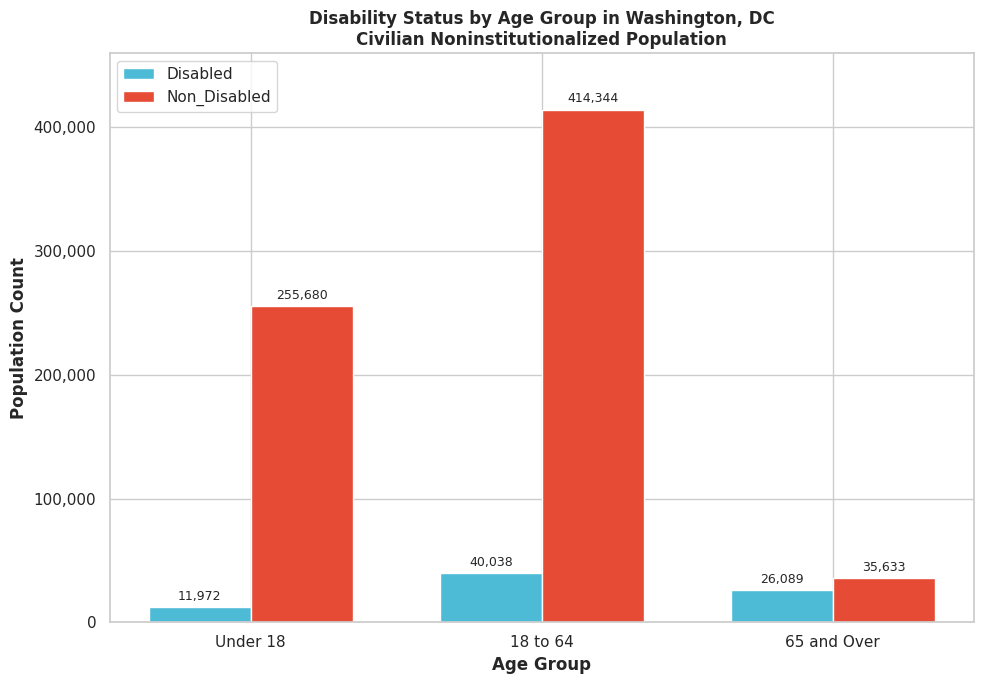

In [ ]:
dc_long = dc_age_disability.melt(id_vars=['Age_Group'], var_name='Status', value_name='Count')
age_order = ["Under 18", "18 to 64", "65 and Over"]
dc_long['Age_Group'] = pd.Categorical(dc_long['Age_Group'], categories=age_order, ordered=True)

fig, ax = plt.subplots(figsize=(10, 7))
bar_width = 0.35
x = range(len(age_order))

disabled_bars = ax.bar([i - bar_width/2 for i in x], dc_age_disability['Disabled'],
                       width=bar_width, label='Disabled', color='#4DBBD5')
non_disabled_bars = ax.bar([i + bar_width/2 for i in x], dc_age_disability['Non_Disabled'],
                           width=bar_width, label='Non_Disabled', color='#E64B35')

ax.set_xlabel('Age Group', fontweight='bold')
ax.set_ylabel('Population Count', fontweight='bold')
ax.set_title('Disability Status by Age Group in Washington, DC\nCivilian Noninstitutionalized Population', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(age_order)
ax.legend(loc='upper left')
ax.set_ylim(0, 460000)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bars in [disabled_bars, non_disabled_bars]:
    for bar in bars:
        ax.annotate(f'{int(bar.get_height()):,}',
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In percentage form, kept only the disabled percentages and printed them in a simple table

In [ ]:
dc_long['Total'] = dc_long.groupby('Age_Group')['Count'].transform('sum')
dc_long['Percentage'] = round((dc_long['Count'] / dc_long['Total']) * 100, 1)

percentages_output = dc_long[dc_long['Status'] == 'Disabled'][['Age_Group', 'Percentage']]
percentages_output = percentages_output.rename(columns={'Percentage': 'Percentage_Disabled'})

print(percentages_output)

     Age_Group  Percentage_Disabled
0     Under 18                  4.5
1     18 to 64                  8.8
2  65 and Over                 42.3


Loading in Curb ramp data and removing blanks and NAs

In [ ]:
curb_clean = curb_data[curb_data['CONDITION'].notna() & (curb_data['CONDITION'] != '')]
curb_counts = curb_clean['CONDITION'].value_counts().reset_index()
curb_counts.columns = ['CONDITION', 'n']

print(curb_counts)

       CONDITION      n
0  Non-Compliant  16139
1           Good  11020
2        Missing   3885
3           Fair   3638


I analyzed the conditions of curb ramps by counting how many ramps fall into each condition category. I first calculated the overall average count to use as a reference line. Then, I created a plot showing each condition, with points sized by count and colored in a gradient. Then, I added a horizontal line for the average and segments connecting the average to each point to make differences easier to see

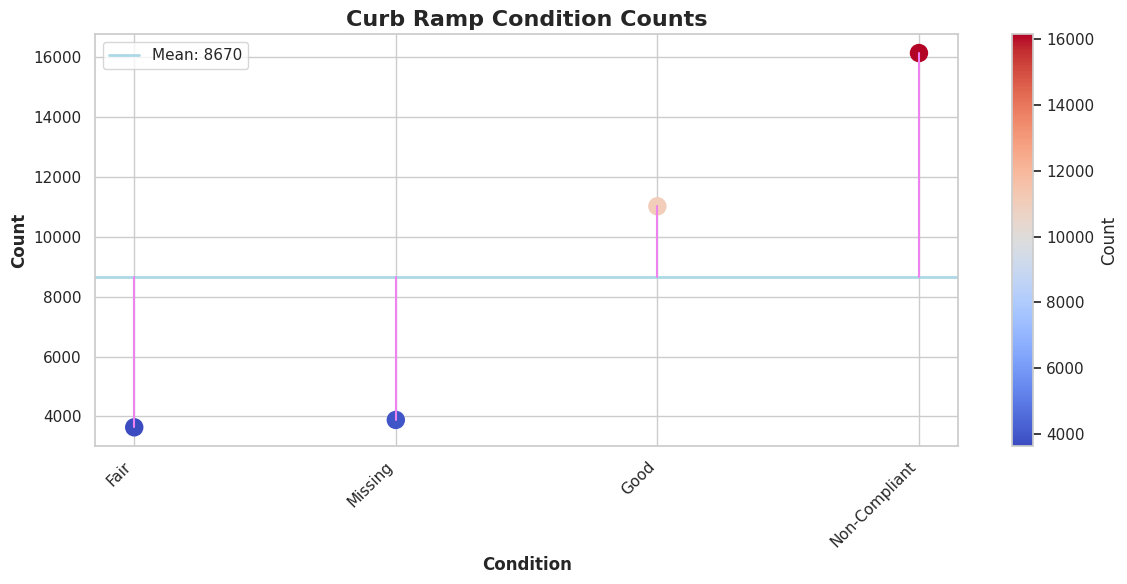

In [ ]:
overall_mean = curb_counts['n'].mean()
curb_counts_sorted = curb_counts.sort_values('n')

fig, ax = plt.subplots(figsize=(12, 6))
conditions = curb_counts_sorted['CONDITION'].tolist()
counts = curb_counts_sorted['n'].tolist()

ax.axhline(y=overall_mean, color='lightblue', linewidth=2, label=f'Mean: {overall_mean:.0f}')

for i, (cond, count) in enumerate(zip(conditions, counts)):
    ax.plot([i, i], [overall_mean, count], color='violet', linewidth=1.5)

scatter = ax.scatter(range(len(conditions)), counts, c=counts, cmap='coolwarm', s=150)
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(conditions, rotation=45, ha='right')
ax.set_ylabel('Count', fontweight='bold')
ax.set_xlabel('Condition', fontweight='bold')
ax.set_title('Curb Ramp Condition Counts', fontweight='bold', fontsize=16)
plt.colorbar(scatter, ax=ax, label='Count')
ax.legend()
plt.tight_layout()
plt.show()

Loading Sidewalk data

In [ ]:
print("Sidewalk data columns:")
print(sidewalk_data.columns.tolist())

Sidewalk data columns:
['DATASTATUS', 'SIDEWALK_LENGTH_FT', 'NUM_MINORCRACKING', 'NUM_SERIOUSCRACKING', 'NUM_SEPARATION', 'NUM_MISSING', 'NUM_SETTLEMENT', 'NUM_PATCHES', 'NUM_SCALING', 'NUM_TREEFOOTDAMAGE', 'OWNERSHIP', 'ID', 'SCI', 'SCI_CATEGORY', 'MAINTENANCEPRIORITY', 'GIS_ID', 'SE_ANNO_CAD_DATA', 'OBJECTID', 'GLOBALID', 'SHAPELEN']


I looked at the sidewalk condition data by counting how many sidewalks fall into each SCI category. I calculated the overall average count to add a reference line to the plot. Then, I made a plot with points for each category, colored by count, and added segments connecting the average line to each point to highlight differences.

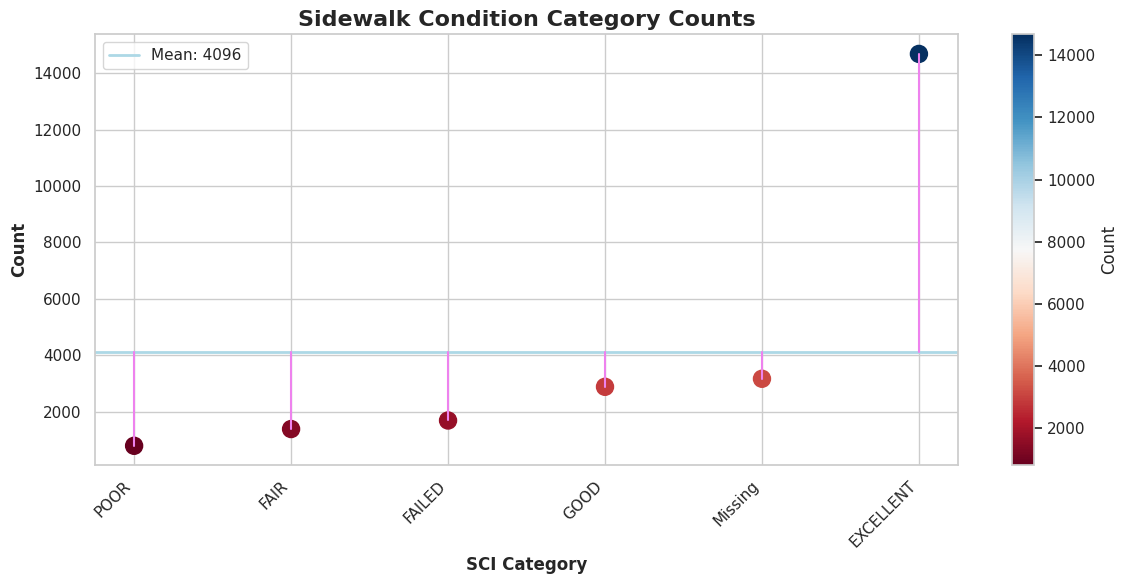


Counts including Missing category:
  SCI_CATEGORY      n
0    EXCELLENT  14679
1      Missing   3164
2         GOOD   2879
3       FAILED   1685
4         FAIR   1382
5         POOR    788


In [ ]:

sidewalk_data['SCI_CATEGORY'] = sidewalk_data['SCI_CATEGORY'].fillna('Missing')
sidewalk_data.loc[sidewalk_data['SCI_CATEGORY'] == '', 'SCI_CATEGORY'] = 'Missing'

sci_counts = sidewalk_data['SCI_CATEGORY'].value_counts().reset_index()
sci_counts.columns = ['SCI_CATEGORY', 'n']

overall_mean_sci = sci_counts['n'].mean()
sci_counts_sorted = sci_counts.sort_values('n')

fig, ax = plt.subplots(figsize=(12, 6))
categories = sci_counts_sorted['SCI_CATEGORY'].tolist()
counts = sci_counts_sorted['n'].tolist()

ax.axhline(y=overall_mean_sci, color='lightblue', linewidth=2, label=f'Mean: {overall_mean_sci:.0f}')

for i, (cat, count) in enumerate(zip(categories, counts)):
    ax.plot([i, i], [overall_mean_sci, count], color='violet', linewidth=1.5)


scatter = ax.scatter(range(len(categories)), counts, c=counts, cmap='RdBu', s=150)
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Count', fontweight='bold')
ax.set_xlabel('SCI Category', fontweight='bold')
ax.set_title('Sidewalk Condition Category Counts', fontweight='bold', fontsize=16)
plt.colorbar(scatter, ax=ax, label='Count')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCounts including Missing category:")
print(sci_counts)

Total Sidewalk Lengths by Condition (SCI_CATEGORY)

In [ ]:
length_by_condition = sidewalk_data.groupby('SCI_CATEGORY')['SIDEWALK_LENGTH_FT'].sum().reset_index()
length_by_condition = length_by_condition.sort_values('SIDEWALK_LENGTH_FT', ascending=False)
length_by_condition = length_by_condition.rename(columns={'SIDEWALK_LENGTH_FT': 'total_length'})

print(length_by_condition)

  SCI_CATEGORY  total_length
0    EXCELLENT       5858510
3         GOOD       1361689
1       FAILED       1041063
2         FAIR        716484
4         POOR        430297


I removed any missing values for both the sidewalk condition category and the total length, then created a bar graph showing the total sidewalk length for each condition. I ordered the bars from greatest to least

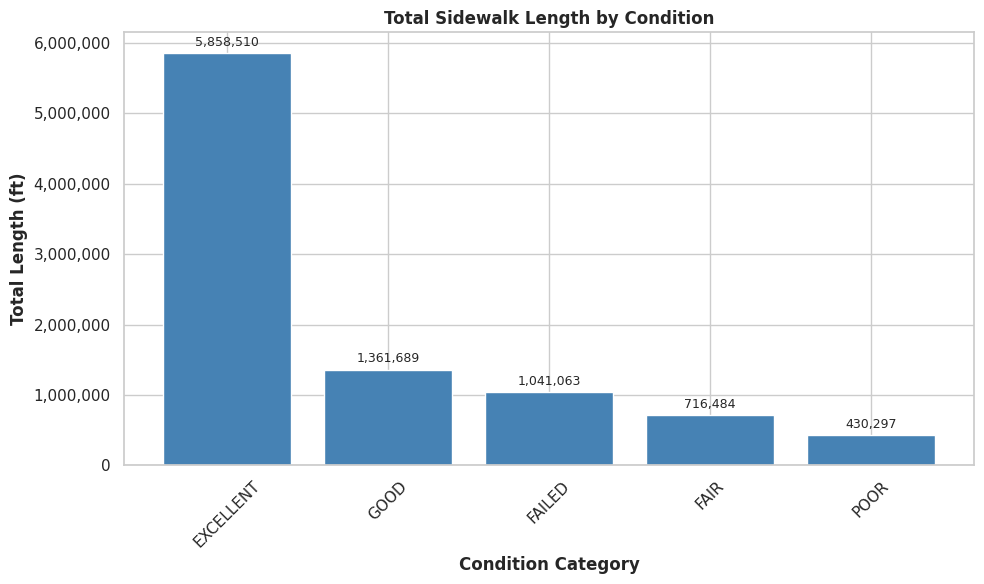

In [ ]:
length_clean = length_by_condition.dropna()
length_clean = length_clean[length_clean['SCI_CATEGORY'] != 'N/A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(length_clean['SCI_CATEGORY'], length_clean['total_length'], color='steelblue')

ax.set_xlabel('Condition Category', fontweight='bold')
ax.set_ylabel('Total Length (ft)', fontweight='bold')
ax.set_title('Total Sidewalk Length by Condition', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

for bar, length in zip(bars, length_clean['total_length']):
    ax.annotate(f'{int(length):,}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Percent of Sidewalks by Maintenance Priority

In [ ]:
priority_counts = sidewalk_data.groupby('MAINTENANCEPRIORITY').size().reset_index(name='count')
priority_counts['percent'] = (priority_counts['count'] / priority_counts['count'].sum()) * 100

print(priority_counts)

  MAINTENANCEPRIORITY  count    percent
0                HIGH   5625  26.269089
1                 LOW   2368  11.058703
2              MEDIUM   1892   8.835754
3                NONE  11528  53.836454


Cross-tab: CI_CATEGORY × MAINTENANCEPRIORITY

In [ ]:
crosstab_counts = pd.crosstab(sidewalk_data['SCI_CATEGORY'], sidewalk_data['MAINTENANCEPRIORITY'])
print(crosstab_counts)

MAINTENANCEPRIORITY  HIGH   LOW  MEDIUM   NONE
SCI_CATEGORY                                  
EXCELLENT               0  2252     899  11528
FAILED               1539     4     142      0
FAIR                 1167    14     201      0
GOOD                 2254    91     534      0
POOR                  665     7     116      0


I made a stacked bar chart to see how maintenance priority is spread across different sidewalk conditions. Each bar shows the proportion of each priority level within a condition, so you can quickly tell which conditions have higher or lower maintenance needs.

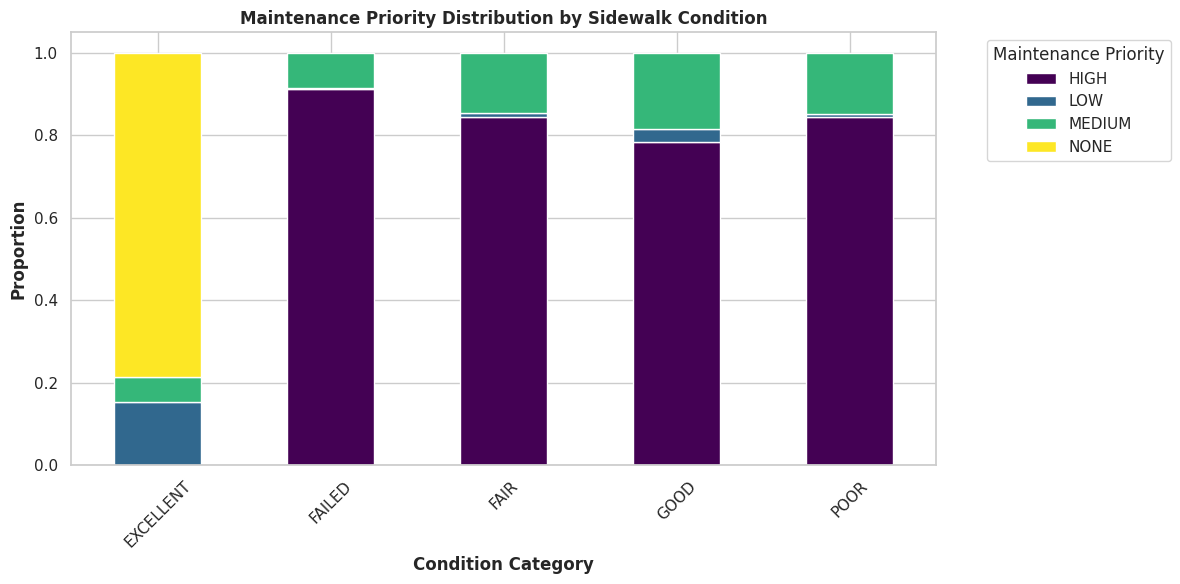

In [ ]:
crosstab_prop = crosstab_counts.div(crosstab_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
crosstab_prop.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

ax.set_xlabel('Condition Category', fontweight='bold')
ax.set_ylabel('Proportion', fontweight='bold')
ax.set_title('Maintenance Priority Distribution by Sidewalk Condition', fontweight='bold')
ax.legend(title='Maintenance Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Length-weighted Cross-tab: This is better than counts because longer sidewalks matter more.

In [ ]:
length_crosstab = sidewalk_data.groupby(['SCI_CATEGORY', 'MAINTENANCEPRIORITY'])['SIDEWALK_LENGTH_FT'].sum().reset_index()
length_crosstab = length_crosstab.rename(columns={'SIDEWALK_LENGTH_FT': 'total_length'})

print(length_crosstab)

   SCI_CATEGORY MAINTENANCEPRIORITY  total_length
0     EXCELLENT                 LOW       1080084
1     EXCELLENT              MEDIUM        389165
2     EXCELLENT                NONE       4389261
3        FAILED                HIGH        963608
4        FAILED                 LOW          2094
5        FAILED              MEDIUM         75361
6          FAIR                HIGH        610374
7          FAIR                 LOW          6958
8          FAIR              MEDIUM         99152
9          GOOD                HIGH       1075365
10         GOOD                 LOW         44099
11         GOOD              MEDIUM        242225
12         POOR                HIGH        363792
13         POOR                 LOW          5610
14         POOR              MEDIUM         60895




Percentage of Fair, Good, Missing, Non-Compliant for Sidewalks



In [ ]:
ramp_percent = curb_counts.copy()
ramp_percent['percent'] = (ramp_percent['n'] / ramp_percent['n'].sum()) * 100

print(ramp_percent)

       CONDITION      n    percent
0  Non-Compliant  16139  46.534225
1           Good  11020  31.774407
2        Missing   3885  11.201776
3           Fair   3638  10.489591


Check results (important)

In [ ]:
print("Run the next chunk first to create curb_clean with CONDITION_GROUP")
print("Current condition values:", curb_counts['CONDITION'].tolist())

Run the next chunk first to create curb_clean with CONDITION_GROUP
Current condition values: ['Non-Compliant', 'Good', 'Missing', 'Fair']


Create condition groups

In [ ]:
def assign_group(condition):
    if condition in ['Good', 'Fair']:
        return 'Compliant'
    elif condition in ['Missing', 'Non-Compliant']:
        return 'Non-compliant'
    else:
        return 'Other'

curb_counts['CONDITION_GROUP'] = curb_counts['CONDITION'].apply(assign_group)
print(curb_counts)

       CONDITION      n CONDITION_GROUP
0  Non-Compliant  16139   Non-compliant
1           Good  11020       Compliant
2        Missing   3885   Non-compliant
3           Fair   3638       Compliant


Calculate group percentages

  CONDITION_GROUP      n    percent
0       Compliant  14658  42.263999
1   Non-compliant  20024  57.736001


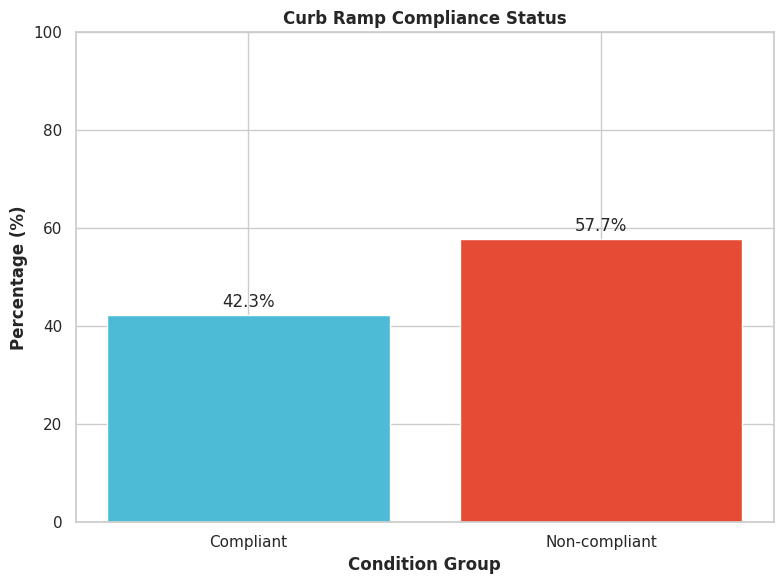

In [ ]:
ramp_percent_grouped = curb_counts.groupby('CONDITION_GROUP')['n'].sum().reset_index()
ramp_percent_grouped['percent'] = (ramp_percent_grouped['n'] / ramp_percent_grouped['n'].sum()) * 100

print(ramp_percent_grouped)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(ramp_percent_grouped['CONDITION_GROUP'], ramp_percent_grouped['percent'],
             color=['#4DBBD5', '#E64B35', 'gray'])

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_xlabel('Condition Group', fontweight='bold')
ax.set_title('Curb Ramp Compliance Status', fontweight='bold')
ax.set_ylim(0, 100)

for bar, pct in zip(bars, ramp_percent_grouped['percent']):
    ax.annotate(f'{pct:.1f}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
               xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()